<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/TimeSeries/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg

Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 21.1MB/s]


In [3]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [4]:
mobile_sales.tail()

,DATE,Sales
212,2018-09-01,13838.0
213,2018-10-01,15351.0
214,2018-11-01,15615.0
215,2018-12-01,16941.0
216,2019-01-01,12160.0


In [5]:
mobile_sales.dtypes

,0
DATE,datetime64[ns]
Sales,float64


#Finding and replacing missing values

In [6]:
mobile_sales.isna().sum()

,0
DATE,0
Sales,19


In [7]:
mobile_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    217 non-null    datetime64[ns]
 1   Sales   198 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [8]:
mobile_sales = mobile_sales.set_index('DATE')
mobile_sales.asfreq(freq='MS')
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


<Axes: xlabel='DATE'>

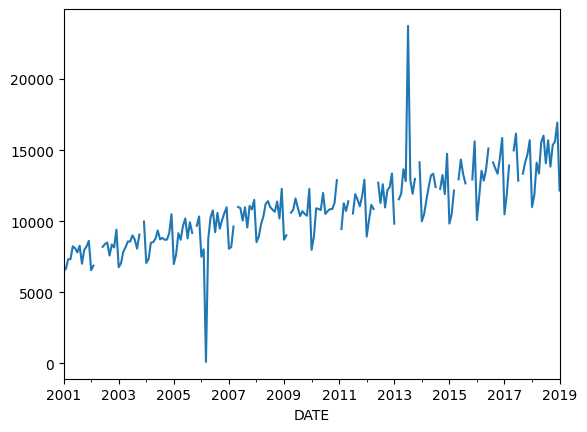

In [9]:
from datetime import date
mobile_sales.Sales.plot(label="Without Imputation")

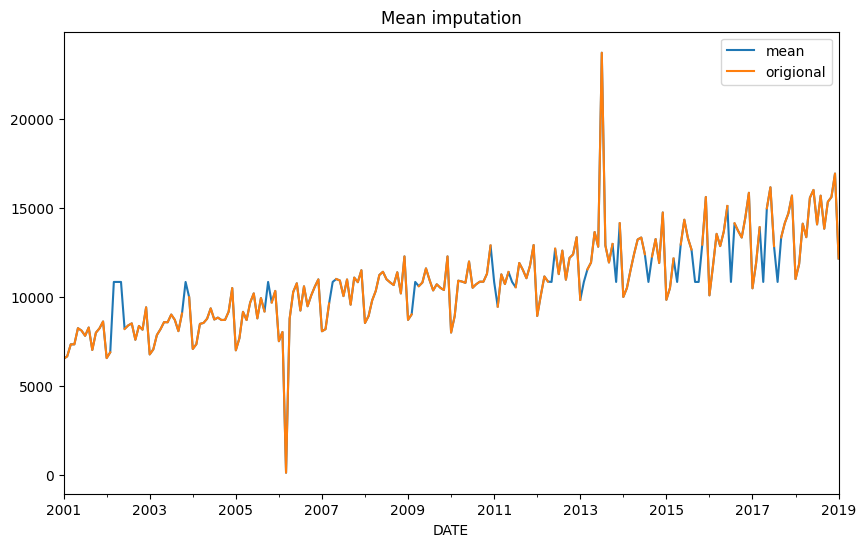

In [10]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.fillna(mobile_sales.Sales.mean()).plot(label="mean")
mobile_sales.Sales.plot(label="origional")
plt.title('Mean imputation')
plt.legend()

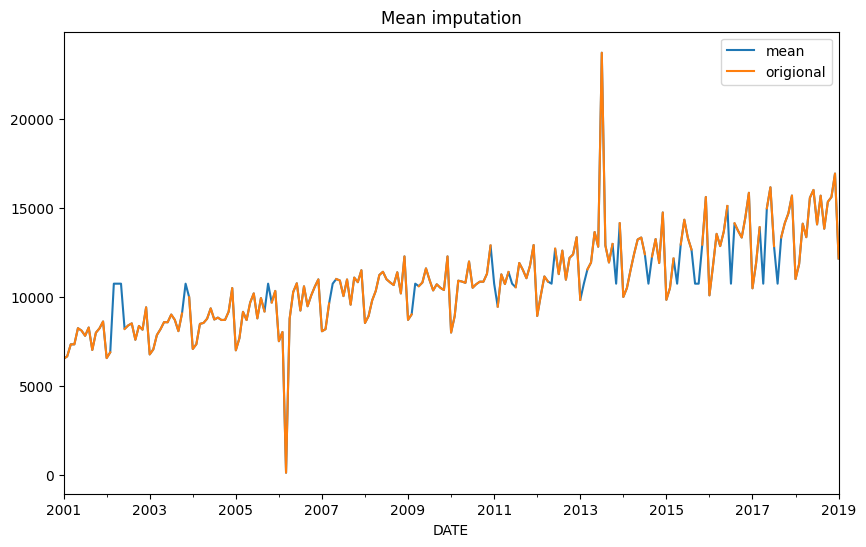

In [11]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.fillna(mobile_sales.Sales.median()).plot(label="mean")
mobile_sales.Sales.plot(label="origional")
plt.title('Mean imputation')
plt.legend()

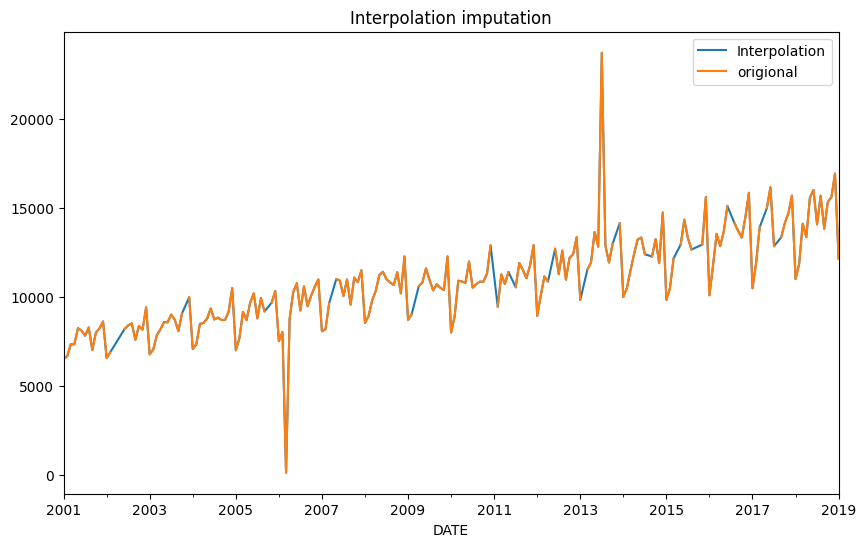

In [12]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.fillna(mobile_sales.Sales.interpolate()).plot(label="Interpolation")
mobile_sales.Sales.plot(label="origional")
plt.title('Interpolation imputation')
plt.legend()

Text(0.5, 1.0, 'Interpolation imputation')

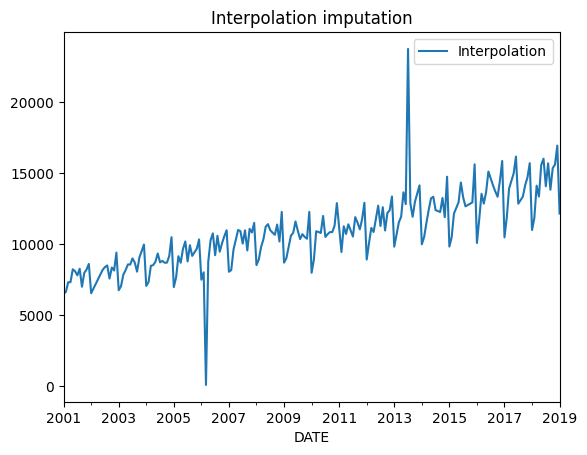

In [13]:
mobile_sales.Sales.fillna(mobile_sales.Sales.interpolate(), inplace=True)
mobile_sales.Sales.fillna(mobile_sales.Sales).plot(label="Interpolation")
plt.legend()
plt.title("Interpolation imputation")

#handelling outliers

[]

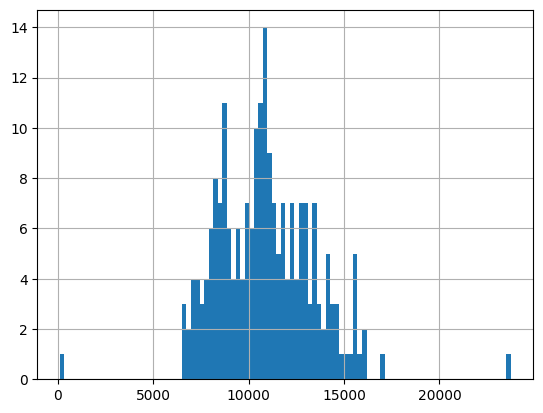

In [14]:
mobile_sales.Sales.hist(bins=100).plot()

The histogram of 'Sales' values provides insights into the distribution of your mobile sales data. Given the typical appearance of such data, we can infer a few things:

*   **Shape:** The histogram likely shows a distribution that is skewed to the right (positively skewed). This means there are more observations at the lower end of the sales spectrum, with a long tail extending towards higher sales values. This is common in sales data, where many periods have moderate sales, and fewer periods have exceptionally high sales.
*   **Central Tendency:** The majority of the sales values are clustered around a certain range, which would represent the most frequent sales amounts.
*   **Spread:** The width of the histogram indicates the variability in sales figures. A wide spread suggests a large range between minimum and maximum sales, while a narrower spread would indicate more consistent sales.
*   **Outliers/Extremes:** The presence of a long tail or isolated bars at the higher end of the sales range could indicate periods of unusually high sales, which might be considered outliers or significant events that boosted sales.

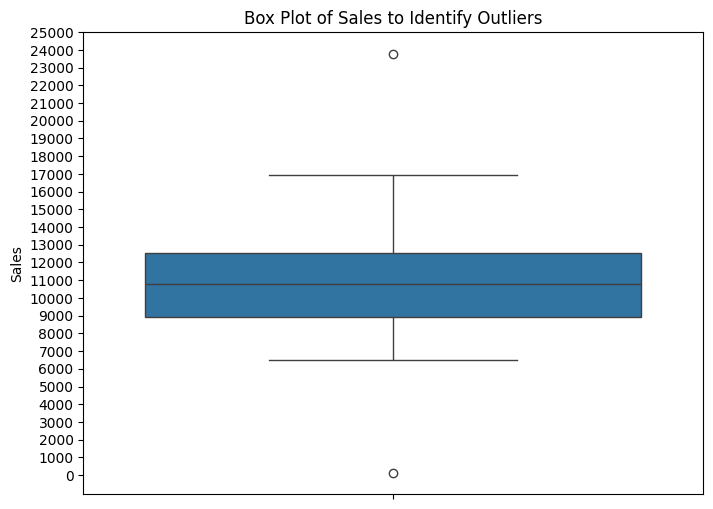

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=mobile_sales['Sales'])
plt.title('Box Plot of Sales to Identify Outliers')
plt.ylabel('Sales')
# Calculate min and max sales for y-axis ticks
min_sales = mobile_sales['Sales'].min()
max_sales = mobile_sales['Sales'].max()
# Generate ticks from min to max with a step of 1000
plt.yticks(np.arange(np.round(min_sales, -3), np.round(max_sales, -3) + 2000, 1000))
plt.show()

In [16]:
Q1 = mobile_sales['Sales'].quantile(0.25)
Q2 = mobile_sales['Sales'].quantile(0.50) # This is also the median
Q3 = mobile_sales['Sales'].quantile(0.75)
IQR = Q3-Q1
low_outlier = Q1 - 1.5 * IQR
high_outlier = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median/50th percentile): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"lower outlier is lesser than: {low_outlier}")
print(f"upper outlier is higher than: {high_outlier}")


Q1 (25th percentile): 8923.0
Q2 (Median/50th percentile): 10793.0
Q3 (75th percentile): 12555.5
IQR: 3632.5
lower outlier is lesser than: 3474.25
upper outlier is higher than: 18004.25


In [17]:
from scipy.stats import percentileofscore

# Percentage of values beyond high_outlier
percentile_high_outlier = percentileofscore(mobile_sales['Sales'], high_outlier, kind='weak')
percentage_beyond_high = 100 - percentile_high_outlier

# Percentage of values less than low_outlier
percentile_low_outlier = percentileofscore(mobile_sales['Sales'], low_outlier, kind='weak')

print(f"Percentage of values beyond {high_outlier:.2f}: {percentage_beyond_high:.2f}%")
print(f"Percentage of values less than {low_outlier:.2f}: {percentile_low_outlier:.2f}%")

Percentage of values beyond 18004.25: 0.46%
Percentage of values less than 3474.25: 0.46%


<Axes: xlabel='DATE'>

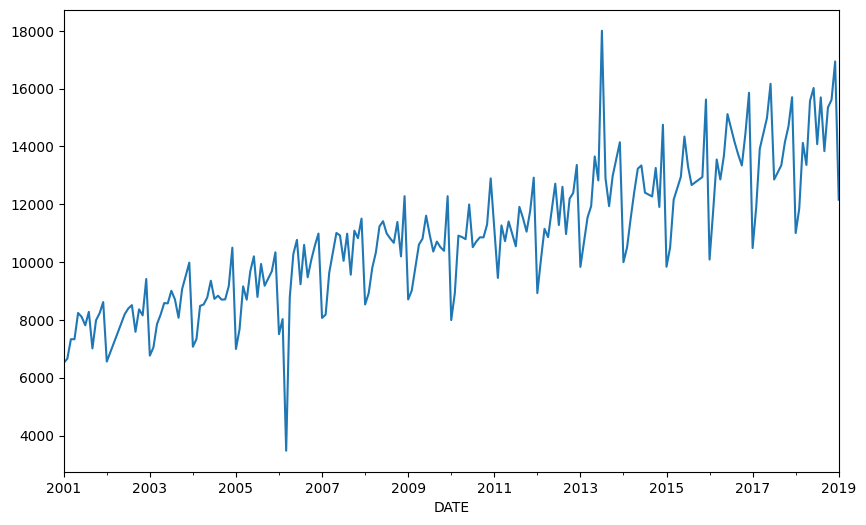

In [18]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.clip(upper=high_outlier, lower=low_outlier).plot()

In [19]:
mobile_sales.Sales.clip(upper=high_outlier, lower=low_outlier, inplace=True)

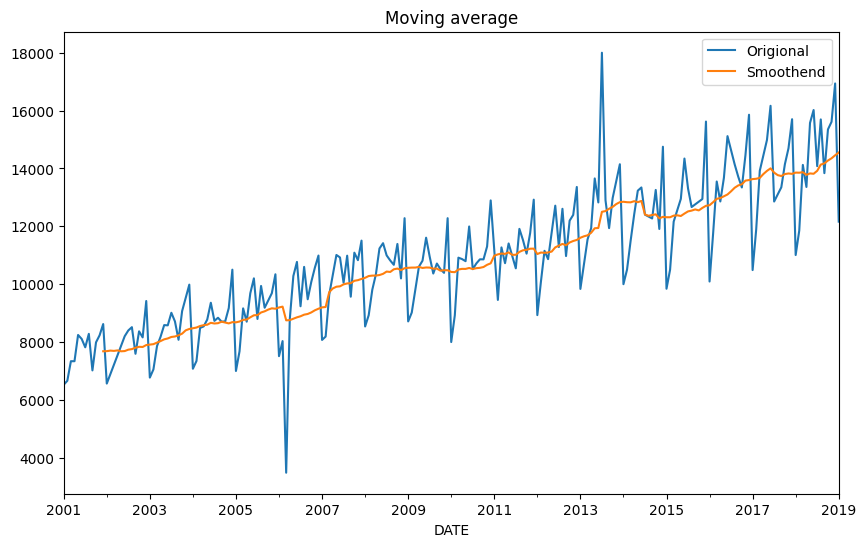

In [20]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.plot(label="Origional")
mobile_sales.Sales.rolling(12).mean().plot(label='Smoothend')
plt.legend()
plt.title("Moving average")
plt.show()

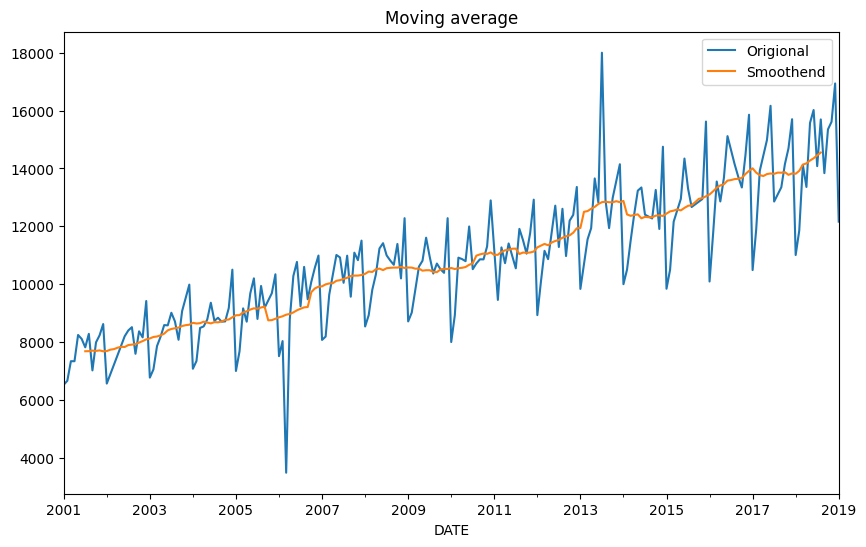

In [21]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.plot(label="Origional")
mobile_sales.Sales.rolling(12,center=True).mean().plot(label='Smoothend')
plt.legend()
plt.title("Moving average")
plt.show()

#Statsmodel.api

In [22]:
import statsmodels.api as sm
model = sm.tsa.seasonal_decompose(mobile_sales.Sales);


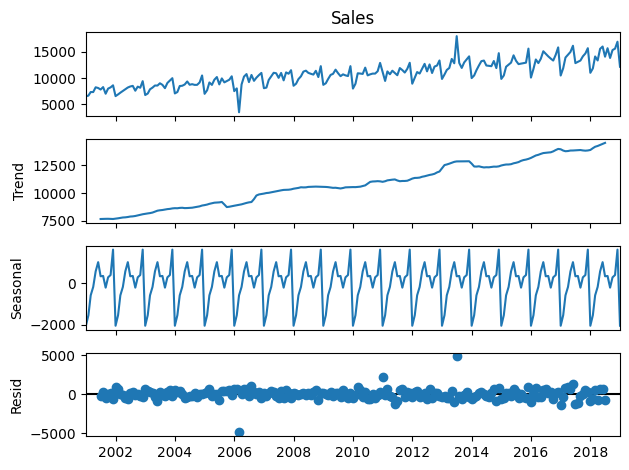

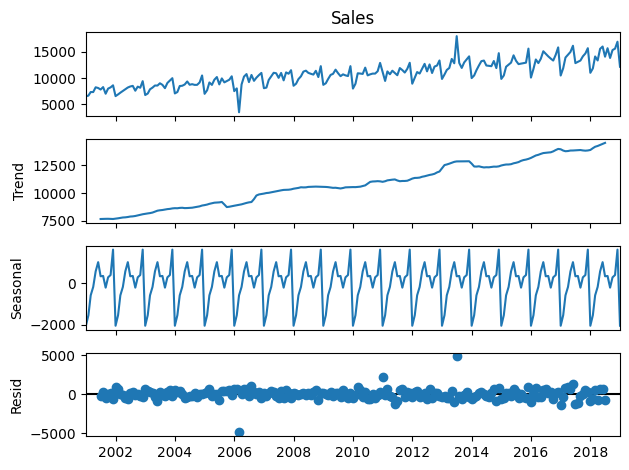

In [23]:
model.plot()

<Axes: xlabel='DATE'>

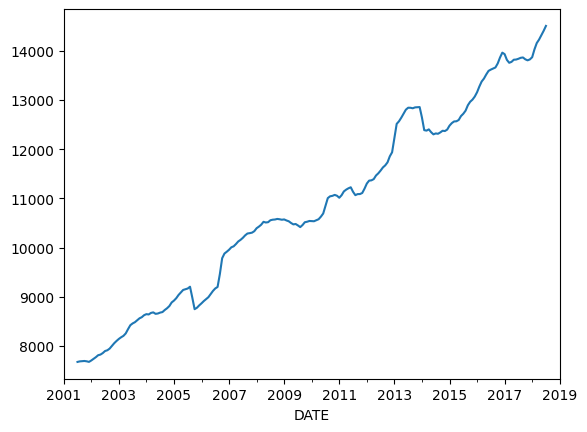

In [24]:
model.trend.plot()

<Axes: xlabel='DATE'>

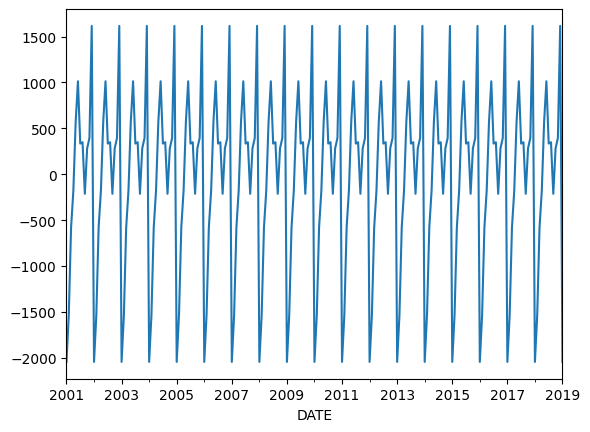

In [25]:
model.seasonal.plot()

<Axes: xlabel='DATE'>

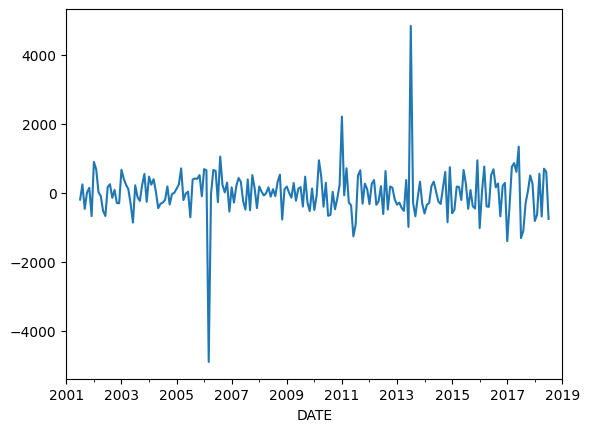

In [26]:
model.resid.plot()

#Train and Test split

In [27]:
mobile_sales.shape

(217, 1)

In [28]:
train_max = mobile_sales.index[-12]
train_max

Timestamp('2018-02-01 00:00:00')

In [29]:
mobile_sales_train = mobile_sales.loc[mobile_sales.index < train_max].copy()
mobile_sales_test = mobile_sales.loc[mobile_sales.index >= train_max].copy()

In [30]:
mobile_sales_train.tail()

,Sales
DATE,
2017-09-01,13349.0
2017-10-01,14150.0
2017-11-01,14698.0
2017-12-01,15704.0
2018-01-01,11005.0


In [31]:
mobile_sales_test.shape

(12, 1)

In [32]:
mobile_sales_train.shape

(205, 1)

#Forecasting
* Mean
* Neive
* Seasonal
* Moving averages
* Drift
* Simple exponential smoothening
* Double exponential smoothening
* Triple exponential smoothening

#Mean Forecasting

In [33]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)


# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

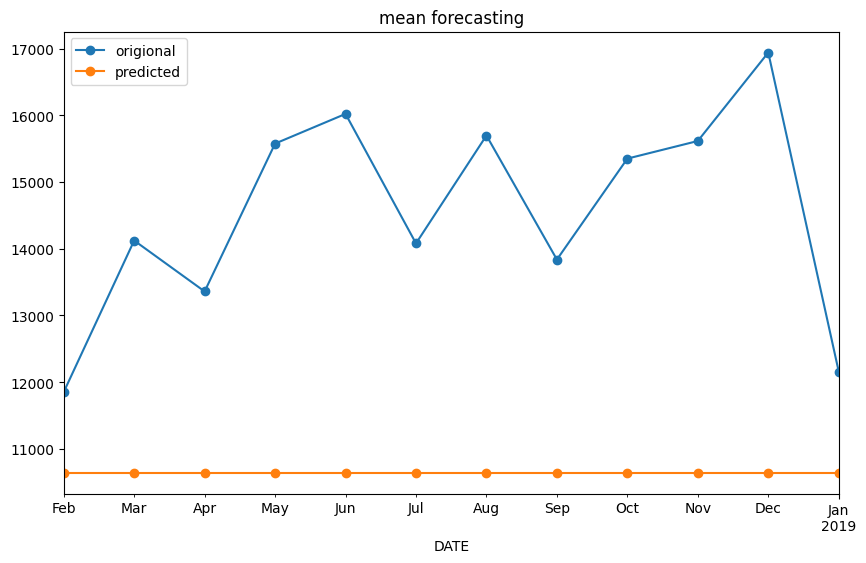

In [34]:
mobile_sales_test['pred_mean'] = mobile_sales_train.Sales.mean()
mobile_sales_test.head()
plt.figure(figsize=(10,6))
mobile_sales_test.Sales.plot(label='origional',style='-o')
mobile_sales_test.pred_mean.plot(label='predicted',style='-o')
plt.legend()
plt.title("mean forecasting")
plt.show()

In [35]:
performance(mobile_sales_test.Sales, mobile_sales_test.pred_mean)

MAE : 3904.984
RMSE : 4186.577
MAPE: 0.26


#Neive forecasting

/tmp/ipykernel_8304/325006145.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mobile_sales_test['pred_neive'] = mobile_sales_train.Sales[-1]


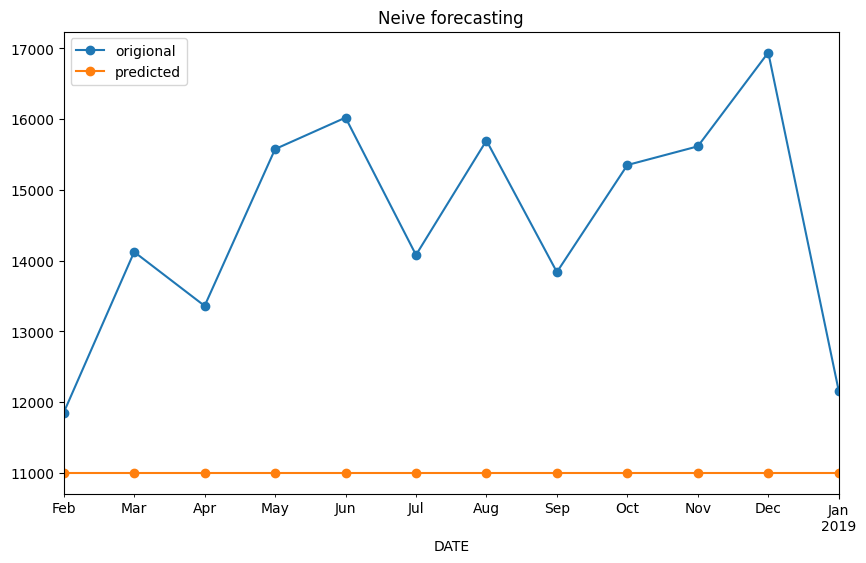

In [36]:
mobile_sales_test['pred_neive'] = mobile_sales_train.Sales[-1]
mobile_sales_test.head()
plt.figure(figsize=(10,6))
mobile_sales_test.Sales.plot(label='origional',style='-o')
mobile_sales_test.pred_neive.plot(label='predicted',style='-o')
plt.legend()
plt.title("Neive forecasting")
plt.show()

In [37]:
performance(mobile_sales_test.Sales, mobile_sales_test.pred_neive)

MAE : 3546.167
RMSE : 3854.067
MAPE: 0.235


#Seasonal Forecasting

In [38]:
mobile_sales_test.index

DatetimeIndex(['2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
               '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
               '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)

In [39]:
mobile_sales_test.index[0]

Timestamp('2018-02-01 00:00:00')

In [40]:
index = mobile_sales_test.index[2]-pd.DateOffset(years=1)

In [41]:
mobile_sales_train.loc[index]

,2017-04-01
Sales,14453.5


In [42]:
mobile_sales_test['pred_seasonal'] = None # Initialize the column

for i in range(mobile_sales_test.shape[0]):
  test_date = mobile_sales_test.index[i]
  index_for_train = test_date - pd.DateOffset(years=1)
  # Get the 'Sales' value from the train set for the corresponding date one year prior
  mobile_sales_test.loc[test_date, 'pred_seasonal'] = mobile_sales_train.loc[index_for_train, 'Sales']
mobile_sales_test

,Sales,pred_mean,pred_neive,pred_seasonal
DATE,,,,
2018-02-01,11852.0,10646.182927,11005.0,11891.0
2018-03-01,14123.0,10646.182927,11005.0,13921.0
2018-04-01,13360.0,10646.182927,11005.0,14453.5
2018-05-01,15576.0,10646.182927,11005.0,14986.0
2018-06-01,16021.0,10646.182927,11005.0,16168.0
2018-07-01,14080.0,10646.182927,11005.0,12856.0
2018-08-01,15697.0,10646.182927,11005.0,13102.5
2018-09-01,13838.0,10646.182927,11005.0,13349.0
2018-10-01,15351.0,10646.182927,11005.0,14150.0


<Axes: xlabel='DATE'>

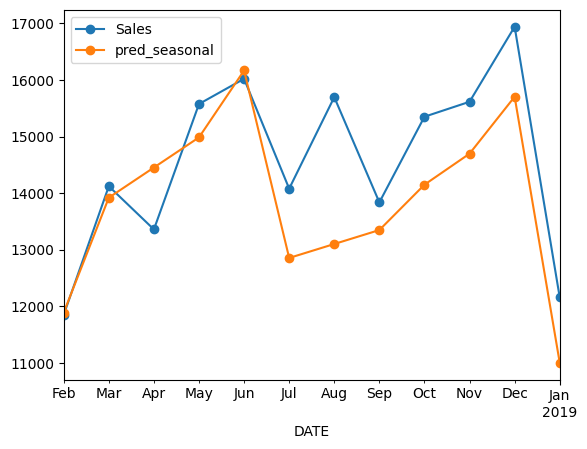

In [43]:
mobile_sales_test[['Sales','pred_seasonal']].plot(style='-o')

In [44]:
performance(mobile_sales_test.Sales, mobile_sales_test.pred_seasonal)

MAE : 907.417
RMSE : 1126.351
MAPE: 0.062


# Moving average forecasting

In [45]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


In [46]:
mobile_sales["pred_rollingmean"] = mobile_sales.Sales.rolling(3).mean()
mobile_sales.head()

,Sales,pred_rollingmean
DATE,,
2001-01-01,6519.0,NaN
2001-02-01,6654.0,NaN
2001-03-01,7332.0,6835.000000
2001-04-01,7332.0,7106.000000
2001-05-01,8240.0,7634.666667


In [47]:
mobile_sales_test['pred_rollingmean'] = mobile_sales.pred_rollingmean[mobile_sales.index>=mobile_sales.index[-12]]
mobile_sales_test

,Sales,pred_mean,pred_neive,pred_seasonal,pred_rollingmean
DATE,,,,,
2018-02-01,11852.0,10646.182927,11005.0,11891.0,12853.666667
2018-03-01,14123.0,10646.182927,11005.0,13921.0,12326.666667
2018-04-01,13360.0,10646.182927,11005.0,14453.5,13111.666667
2018-05-01,15576.0,10646.182927,11005.0,14986.0,14353.000000
2018-06-01,16021.0,10646.182927,11005.0,16168.0,14985.666667
2018-07-01,14080.0,10646.182927,11005.0,12856.0,15225.666667
2018-08-01,15697.0,10646.182927,11005.0,13102.5,15266.000000
2018-09-01,13838.0,10646.182927,11005.0,13349.0,14538.333333
2018-10-01,15351.0,10646.182927,11005.0,14150.0,14962.000000


<Axes: xlabel='DATE'>

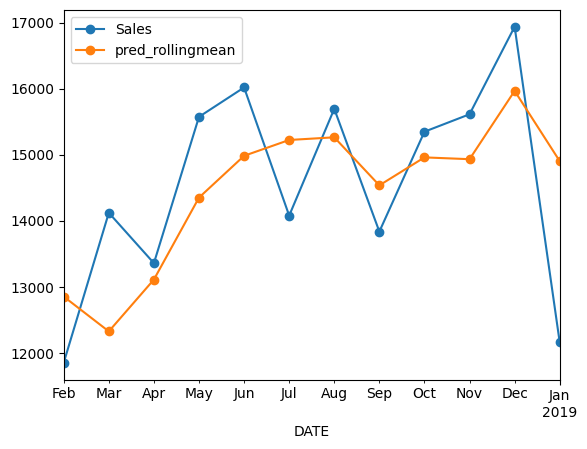

In [48]:
mobile_sales_test[['Sales','pred_rollingmean']].plot(style='-o')

In [49]:
performance(mobile_sales_test.Sales, mobile_sales_test.pred_rollingmean)

MAE : 1030.694
RMSE : 1222.84
MAPE: 0.074


#Drift Forecasting

In [50]:
mobile_sales_train.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


In [51]:
yt = mobile_sales_train['Sales'][-1]
m = (yt - mobile_sales_train['Sales'][0]) / len(mobile_sales_train)

/tmp/ipykernel_8304/2211536602.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yt = mobile_sales_train['Sales'][-1]
/tmp/ipykernel_8304/2211536602.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m = (yt - mobile_sales_train['Sales'][0]) / len(mobile_sales_train)


In [52]:
h = np.arange(0,12)

In [53]:
h

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [54]:
mobile_sales_test['pred_drift'] = yt + m*h
mobile_sales_test

,Sales,pred_mean,pred_neive,pred_seasonal,pred_rollingmean,pred_drift
DATE,,,,,,
2018-02-01,11852.0,10646.182927,11005.0,11891.0,12853.666667,11005.000000
2018-03-01,14123.0,10646.182927,11005.0,13921.0,12326.666667,11026.882927
2018-04-01,13360.0,10646.182927,11005.0,14453.5,13111.666667,11048.765854
2018-05-01,15576.0,10646.182927,11005.0,14986.0,14353.000000,11070.648780
2018-06-01,16021.0,10646.182927,11005.0,16168.0,14985.666667,11092.531707
2018-07-01,14080.0,10646.182927,11005.0,12856.0,15225.666667,11114.414634
2018-08-01,15697.0,10646.182927,11005.0,13102.5,15266.000000,11136.297561
2018-09-01,13838.0,10646.182927,11005.0,13349.0,14538.333333,11158.180488
2018-10-01,15351.0,10646.182927,11005.0,14150.0,14962.000000,11180.063415


<Axes: xlabel='DATE'>

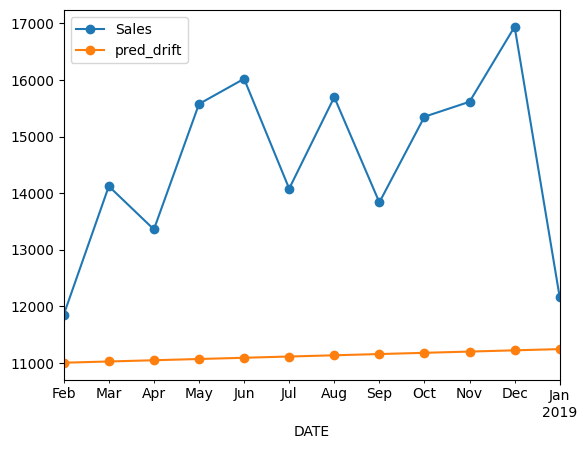

In [55]:
mobile_sales_test[['Sales','pred_drift']].plot(style='-o')

In [56]:
performance(mobile_sales_test['Sales'],mobile_sales_test['pred_drift'])

MAE : 3425.811
RMSE : 3735.003
MAPE: 0.227


#Sinple exponnetial smoothening

In [57]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level = 0.8)
pred = model.forecast(12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [58]:
mobile_sales

,Sales,pred_rollingmean
DATE,,
2001-01-01,6519.0,NaN
2001-02-01,6654.0,NaN
2001-03-01,7332.0,6835.000000
2001-04-01,7332.0,7106.000000
2001-05-01,8240.0,7634.666667
...,...,...
2018-09-01,13838.0,14538.333333
2018-10-01,15351.0,14962.000000
2018-11-01,15615.0,14934.666667


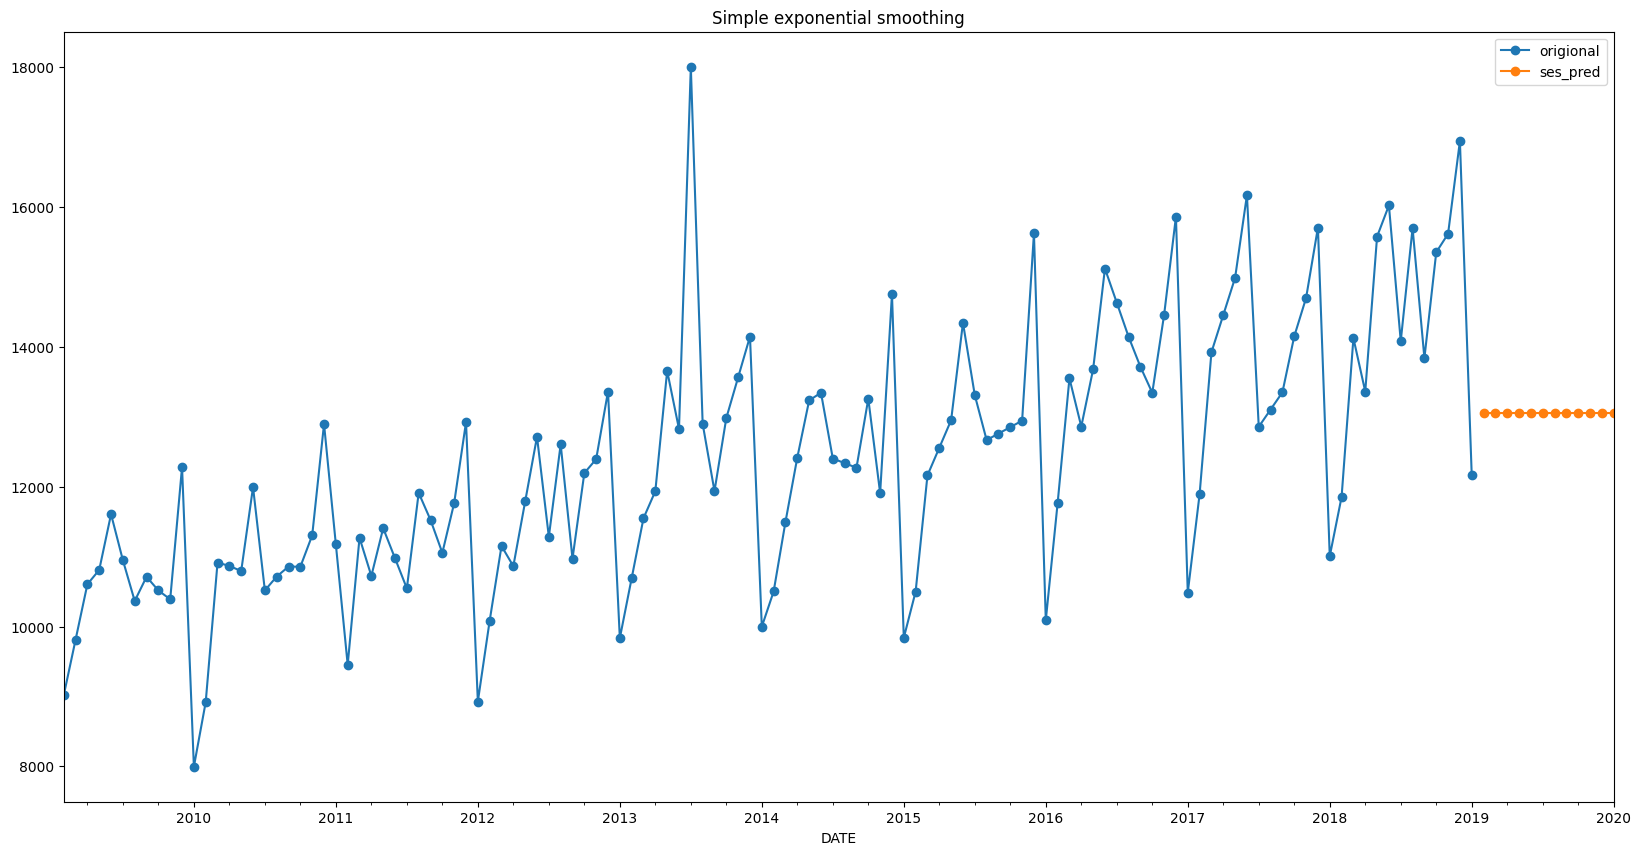

In [59]:
plt.figure(figsize=(20,10))
mobile_sales.Sales[-120:].plot(style='-o', label='origional')
pred.plot(style='-o', label='ses_pred')
plt.legend()
plt.title("Simple exponential smoothing")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


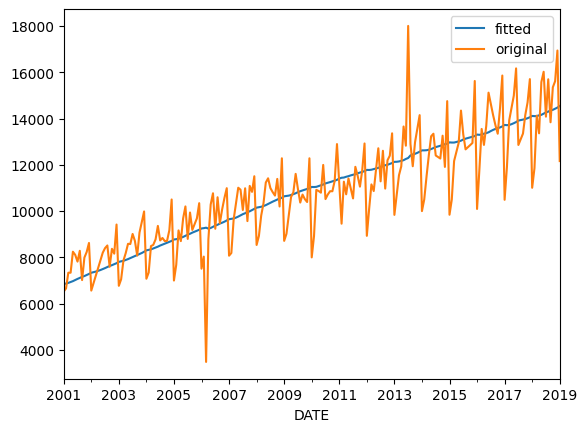

In [60]:
# just by adding trend -> DES

model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend="add").fit(smoothing_trend=0.02);
model.fittedvalues.plot(label="fitted")
mobile_sales.Sales.plot(label="original")
plt.legend()
plt.show()

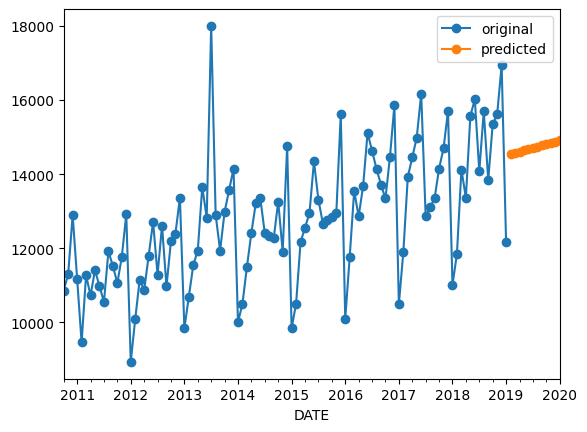

In [61]:
pred = model.forecast(12)

mobile_sales.Sales.tail(100).plot(label="original", style='-o')
pred.plot(label="predicted", style='-o')
plt.legend()

In [62]:
#TES
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend="add", seasonal="add").fit();

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


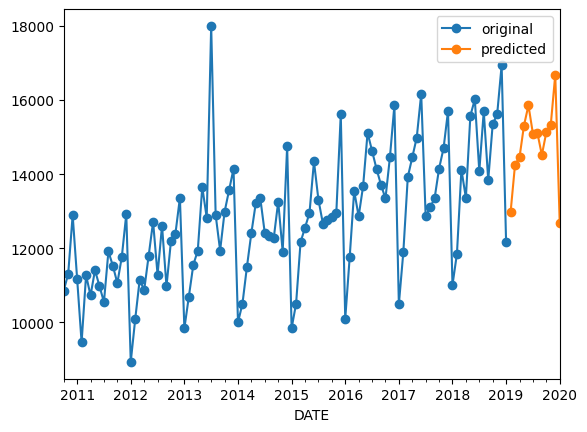

In [63]:
pred = model.forecast(12)

mobile_sales.Sales.tail(100).plot(label="original", style='-o')
pred.plot(label="predicted", style='-o')
plt.legend()

#ADF Stationarity test

In [64]:
sm.tsa.stattools.adfuller(mobile_sales.Sales)

(np.float64(0.33026740351548556),
 np.float64(0.9786913090538084),
 11,
 205,
 {'1%': np.float64(-3.4626576734812318),
  '5%': np.float64(-2.8757444215841326),
  '10%': np.float64(-2.5743412314098753)},
 np.float64(3360.803784328497))

In [65]:
p_value = sm.tsa.stattools.adfuller(mobile_sales.Sales)[1]
p_value

np.float64(0.9786913090538084)

In [66]:
singnificance_level = 0.01
if p_value > singnificance_level:
  print("Non Stationary")
if p_value < singnificance_level:
  print("Stationary")

Non Stationary


#Making TS Stationary

In [67]:
p_value = sm.tsa.stattools.adfuller(mobile_sales.Sales.diff(1).dropna())[1]
p_value

np.float64(4.869120240543937e-29)

In [68]:
if p_value > singnificance_level:
  print("Non Stationary")
if p_value < singnificance_level:
  print("Stationary")

Stationary


#Finding seasonality using Autocorrelation and Partial auto correlation

In [69]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

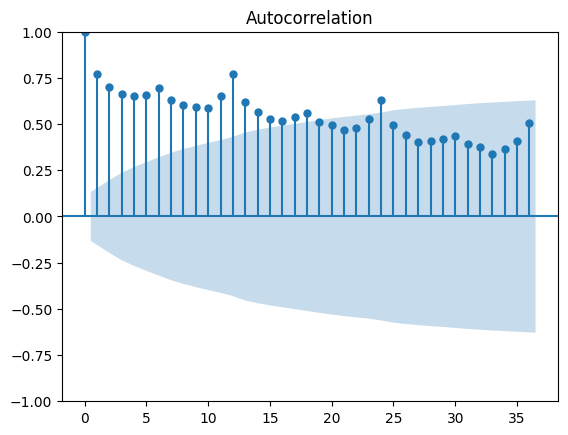

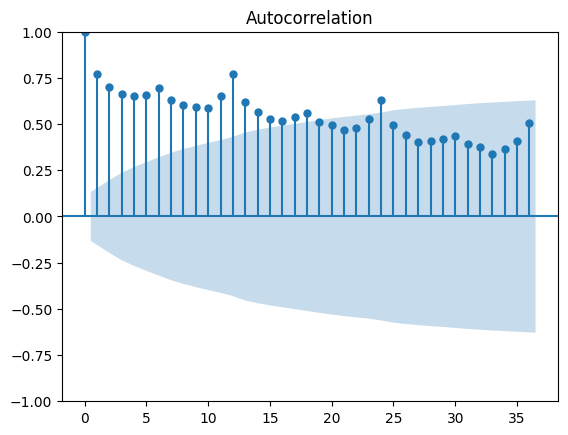

In [70]:
plot_acf(mobile_sales.Sales, lags=36)

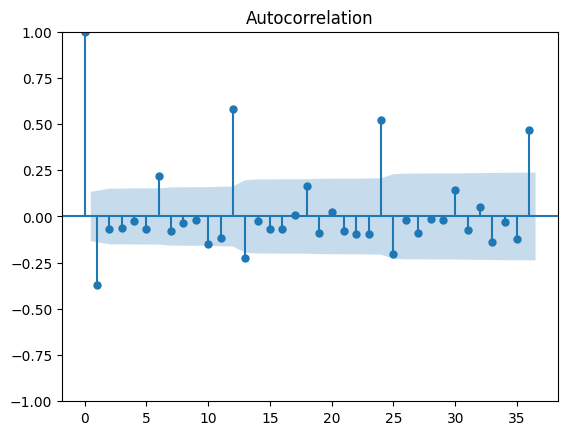

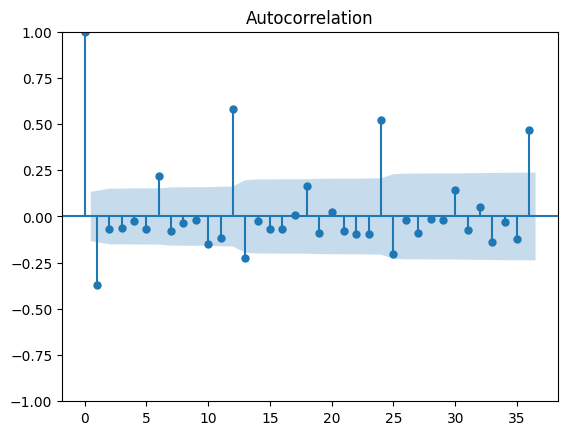

In [71]:
plot_acf(mobile_sales.Sales.diff(1).dropna(), lags=36)

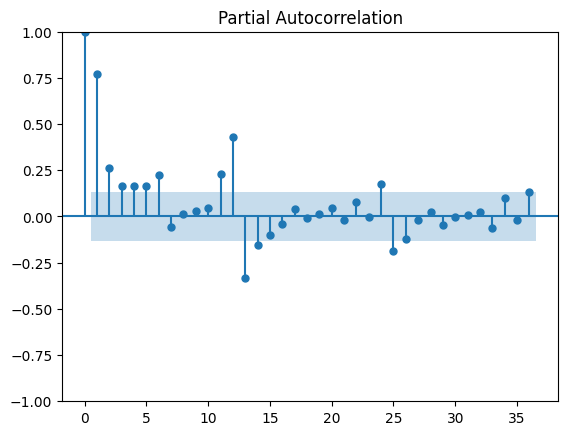

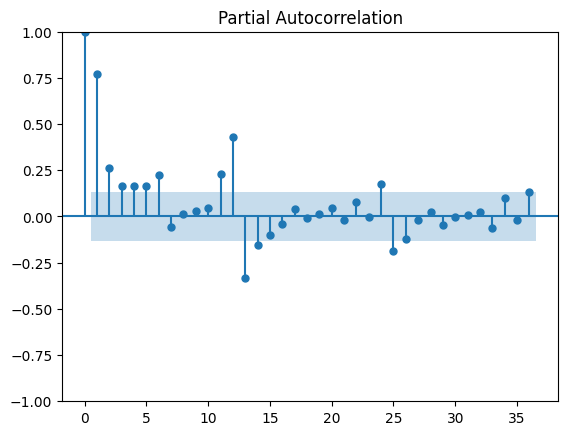

In [72]:
plot_pacf(mobile_sales.Sales, lags=36)

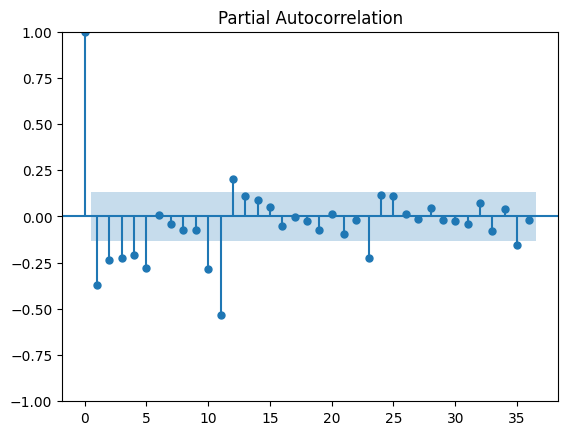

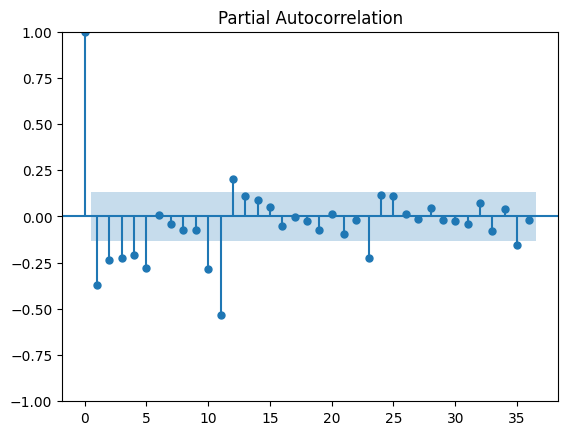

In [73]:
plot_pacf(mobile_sales.Sales.diff(1).dropna(), lags=36)

##Seasonality is 12 months

In [74]:
mobile_sales.head()

,Sales,pred_rollingmean
DATE,,
2001-01-01,6519.0,NaN
2001-02-01,6654.0,NaN
2001-03-01,7332.0,6835.000000
2001-04-01,7332.0,7106.000000
2001-05-01,8240.0,7634.666667


In [75]:
mobile_sales.drop(["pred_rollingmean"], axis=1, inplace=True)
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


In [76]:
train_max_date = mobile_sales.index[-12]
train_max_date

Timestamp('2018-02-01 00:00:00')

In [77]:
train_x = mobile_sales.loc[mobile_sales.index < train_max_date].copy()
test_x = mobile_sales.loc[mobile_sales.index >= train_max_date].copy()

In [78]:
train_x.shape

(205, 1)

In [79]:
test_x.shape

(12, 1)

<Axes: xlabel='DATE'>

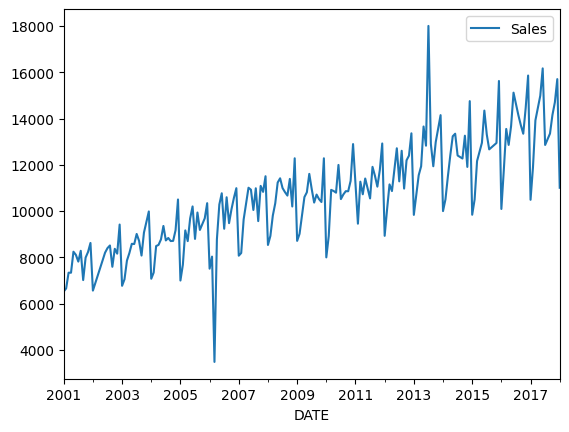

In [80]:
train_x.plot()

<Axes: xlabel='DATE'>

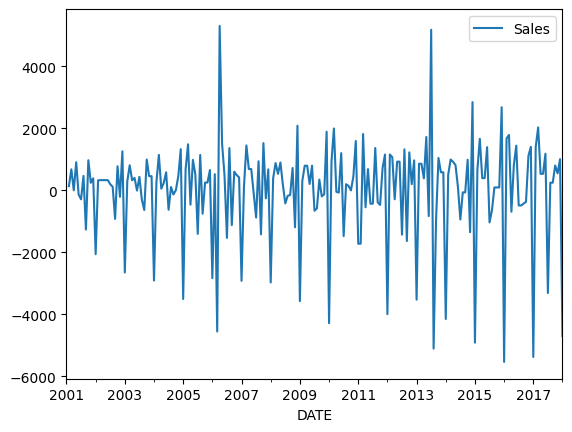

In [81]:
train_x.diff(1).plot()

#SARIMAX Model: Prediction with learnable model

In [82]:
from statsmodels.tsa.statespace.sarimax import SARIMAX # supermodel.

#Auto Regression

In [83]:
test_x.head()

,Sales
DATE,
2018-02-01,11852.0
2018-03-01,14123.0
2018-04-01,13360.0
2018-05-01,15576.0
2018-06-01,16021.0


In [90]:
#order=(AR,d,MA)
#AR--> How many past values to consider for prediction. Using seasonal value is best for performance.
#d--> Diff level to make the series stationary. 0 if TS is already stationary.
#MA--> How many past error values to consider for prediction. Using seasonal value is best for performance.
model = SARIMAX(train_x.Sales.diff(1).dropna(), order=(3,0,0)).fit(disp=False)
test_x['pred']= model.forecast(steps=12)#predict next 12 values
test_x

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Sales,pred
DATE,,
2018-02-01,11852.0,2013.614675
2018-03-01,14123.0,373.263589
2018-04-01,13360.0,209.366155
2018-05-01,15576.0,-731.480573
2018-06-01,16021.0,225.046810
2018-07-01,14080.0,92.561980
2018-08-01,15697.0,46.006190
2018-09-01,13838.0,-112.106891
2018-10-01,15351.0,20.959620


<Axes: xlabel='DATE'>

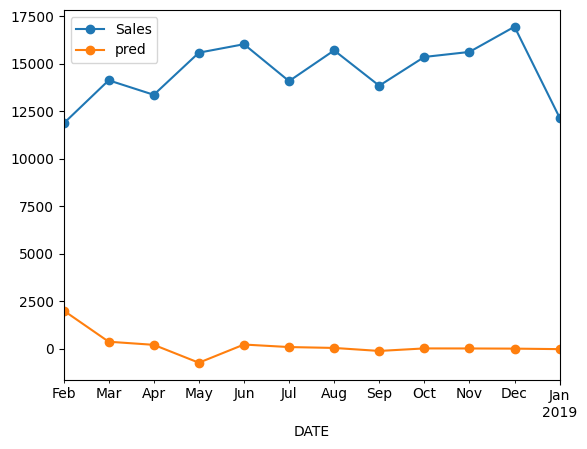

In [91]:
test_x.plot(style='-o')

In [93]:
test_x.drop(columns=['pred'],inplace=True)
test_x

,Sales
DATE,
2018-02-01,11852.0
2018-03-01,14123.0
2018-04-01,13360.0
2018-05-01,15576.0
2018-06-01,16021.0
2018-07-01,14080.0
2018-08-01,15697.0
2018-09-01,13838.0
2018-10-01,15351.0


In [99]:
train_x.iloc[-1]["Sales"]


np.float64(11005.0)

train_x.iloc[-1]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_8304/3980878229.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]


<Axes: xlabel='DATE'>

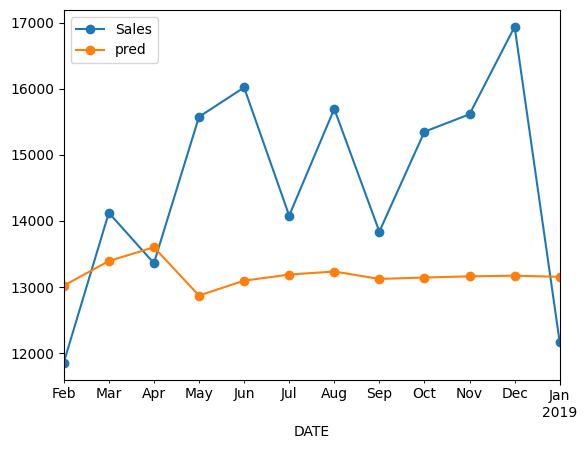

In [102]:
#order=(AR,d,MA)
#AR--> How many past values to consider for prediction. Using seasonal value is best for performance.
#d--> Diff level to make the series stationary. 0 if TS is already stationary.
#MA--> How many past error values to consider for prediction. Using seasonal value is best for performance.
model = SARIMAX(train_x.Sales.diff(1).dropna(), order=(3,0,0)).fit(disp=False)
test_x['pred']= model.forecast(steps=12)#predict next 12 values
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]# to interpret predictions on the original sales scale
test_x.plot(style='-o')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_8304/2081944608.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]# to interpret predictions on the original sales scale


<Axes: xlabel='DATE'>

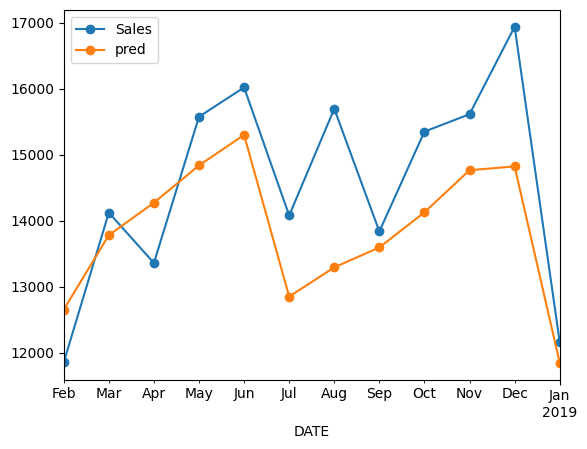

In [103]:
#order=(AR,d,MA)
#AR--> How many past values to consider for prediction. Using seasonal value is best for performance.
#d--> Diff level to make the series stationary. 0 if TS is already stationary.
#MA--> How many past error values to consider for prediction. Using seasonal value is best for performance.
model = SARIMAX(train_x.Sales.diff(1).dropna(), order=(12,0,0)).fit(disp=False)#use AR=12 as seasonality is 12
test_x['pred']= model.forecast(steps=12)#predict next 12 values
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]# to interpret predictions on the original sales scale
test_x.plot(style='-o')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

<Axes: xlabel='DATE'>

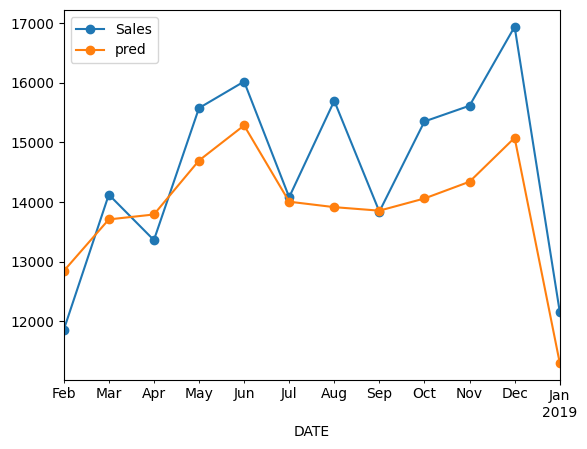

In [104]:
#order=(AR,d,MA)
#AR--> How many past values to consider for prediction. Using seasonal value is best for performance.
#d--> Diff level to make the series stationary. 0 if TS is already stationary.
#MA--> How many past error values to consider for prediction. Using seasonal value is best for performance.
model = SARIMAX(train_x.Sales.diff(1).dropna(), order=(12,0,12)).fit(disp=False)#use AR=12 as seasonality is 12
test_x['pred']= model.forecast(steps=12)#predict next 12 values
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]# to interpret predictions on the original sales scale
test_x.plot(style='-o')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

<Axes: xlabel='DATE'>

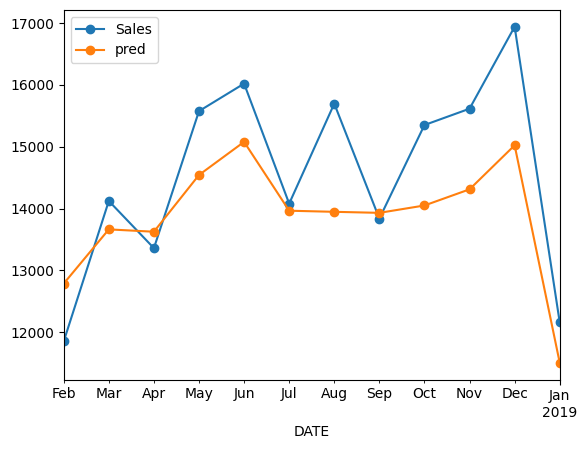

In [105]:
#order=(AR,d,MA)
#AR--> How many past values to consider for prediction. Using seasonal value is best for performance.
#d--> Diff level to make the series stationary. 0 if TS is already stationary.
#MA--> How many past error values to consider for prediction. Using seasonal value is best for performance.
model = SARIMAX(train_x.Sales, order=(12,1,12)).fit(disp=False)#use AR=12 as seasonality is 12
test_x['pred']= model.forecast(steps=12)#predict next 12 values
#test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]# to interpret predictions on the original sales scale
test_x.plot(style='-o')